<a href="https://colab.research.google.com/github/ekmorozova111/26-Detection-object-recognition/blob/main/checkpoint6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В этом чекпойнте поэкспериментировала с архитектурой трансформера RF-DETR. Я выбрала 5 эпох, так как максимальная длина сессии на Кэгле 12 часов, больше не получается. Одна эпоха длится примерно два с лишним часа.   
RF-DETR — это архитектура трансформера реального времени для задач детекции и сегментации, разработанная компанией Roboflow. Построенный на основной базе архитектуры трансформера DINOv2, RF-DETR обеспечивает высокую точность и скорость работы на датасетах Microsoft COCO и RF100-VL.
 Основные модели (от Nano до Large) и весь код выпускаются под лицензией Apache 2.0.

In [ ]:
#установка библиотеки для оценки объектов детекции
!pip install faster-coco-eval --quiet

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 9.7 MB/s eta 0:00:00

In [ ]:
# Установка библиотеки rfdetr
!pip install rfdetr[metrics] --quiet

WARNING: rfdetr 1.6.5 does not provide the extra 'metrics'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.2/253.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.2 MB/s eta 0:00:00

In [ ]:
from rfdetr import RFDETRBase
import os

# 1. Настройка путей
# Я поставила путь к своему датасету
DATASET_PATH = "/kaggle/input/datasets/ekaterinamorozova29/coco-gun-dataset2/coco_gundataset"
OUTPUT_PATH = "/kaggle/working/output"

# 2. Инициализация модели RF-DETR Base
model = RFDETRBase()

# 3. Запуск обучения
model.train(
    dataset_dir=DATASET_PATH,
    epochs=5,             # Количество эпох
    batch_size=4,          # Размер батча
    grad_accum_steps=4,    # Накопление градиента для имитации батча 16
    lr=1e-4,               # Скорость обучения
    output_dir=OUTPUT_PATH,
    device="cuda"          # Параметра для GPU
)

[2026-04-30 16:33:25] [INFO] rf-detr - Downloading pretrained weights for rf-detr-base.pth
[2026-04-30 16:33:30] [INFO] rf-detr - MD5 validation successful for rf-detr-base.pth
[2026-04-30 16:33:32] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-30 16:33:37] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-30 16:33:38] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-30 16:33:41.323351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
E0000 00:00:1777566821.547172      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777566821.615170      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777566822.255329      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777566822.255363      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777566822.255382      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777566822.255385      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
[2026-04-30 16:33:56] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 560
[2026-04-30 16:33:56] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-04-30 16:33:56] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-30 16:33:56] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
[2026-04-30 16:33:56] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 560
[2026-04-30 16:33:56] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-04-30 16:33:56] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/output exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

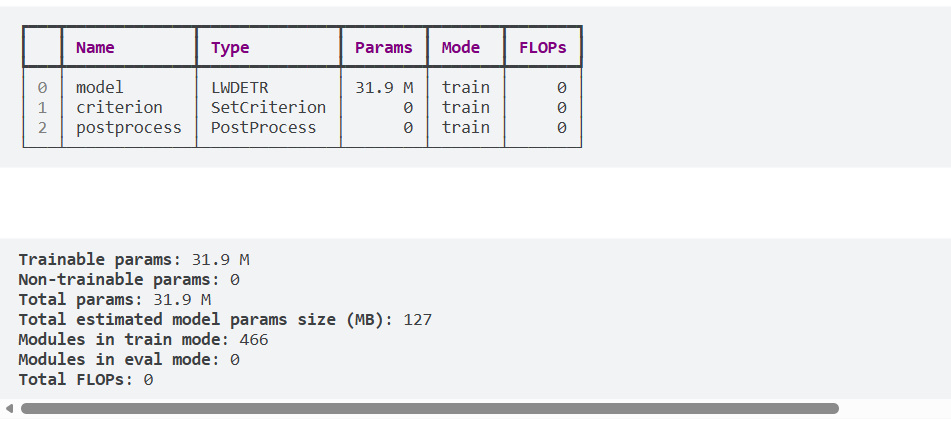

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
[2026-04-30 16:34:03] [INFO] rf-detr - Best EMA mAP improved to 0.0159 (epoch 0)
[2026-04-30 18:55:34] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/output/checkpoint_best_regular.pth (epoch 0)
[2026-04-30 18:55:34] [INFO] rf-detr - Best EMA mAP improved to 0.7124 (epoch 0)
[2026-04-30 21:19:51] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/output/checkpoint_best_regular.pth (epoch 1)
[2026-04-30 21:19:52] [INFO] rf-detr - Best EMA mAP improved to 0.7239 (epoch 1)
[2026-04-30 23:44:15] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/output/checkpoint_best_regular.pth (epoch 2)
[2026-04-30 23:44:15] [INFO] rf-detr - Best EMA mAP improved to 0.7359 (epoch 2)
[2026-05-01 04:28:26] [INFO] rf-detr - Best regular mAP saved to /kaggle/working/output/checkpoint_best_regular.pth (epoch 4)
[2026-05-01 04:28:27] [INFO] rf-detr - Best EMA mAP improved to 0.7434 (epoch 4)
`Trainer.fit` stopped: `max_epochs=5` reached.
[2026-05-01 04:28:30] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7143, ema=0.7434)

 После того как я обучила трансформер сравню его с моделью YOLO11s со стандартными гиперпараметрами обученной в 5 чекпоинте.

In [ ]:
# Установка библиотеки rfdetr
!pip install rfdetr[metrics] --quiet

WARNING: rfdetr 1.6.5.post0 does not provide the extra 'metrics'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.2/253.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 109.4 MB/s eta 0:00:00

In [ ]:
import torch
from rfdetr import RFDETRBase
import os
from pathlib import Path
from tqdm import tqdm

# 1. Настройки путей для моего обученного трансформера
BEST_MODEL_PATH = "/kaggle/input/models/ekaterinamorozova29/rf-detr-gun/transformers/default/1/checkpoint_best_ema.pth"
TEST_DATASET_PATH = "/kaggle/input/datasets/ekaterinamorozova29/coco-gun-dataset2/coco_gundataset/test" # Путь к папке с картинками
OUTPUT_DIR = Path("rf_detr_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# 2. Инициализация и загрузка (исправленная схема для 2 классов + фон)
try:
    model_wrapper = RFDETRBase(num_classes=2)
except TypeError:
    model_wrapper = RFDETRBase(model_config={'num_classes': 2})

# Загрузка весов напрямую во внутреннюю структуру
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cuda')
state_dict = checkpoint.get('model', checkpoint.get('state_dict', checkpoint))

model_wrapper.model.model.load_state_dict(state_dict)
model_wrapper.model.model.to("cuda")
model_wrapper.model.model.eval()

print("✅ Модель RF-DETR готова. Начинаем инференс...")

# 3. Цикл предсказания по тестовой выборке
test_images = list(Path(TEST_DATASET_PATH).glob("*.jpg"))

results_summary = []

for img_path in tqdm(test_images[:10], desc="Predicting"): # Берем первые 10 для теста
    # Вызываем метод predict
    # conf - порог уверенности, такой же как вы ставили для YOLO
    result = model_wrapper.predict(str(img_path), conf=0.25)

    # Сохраняем информацию для сравнения
    # В большинстве DETR-оберток результат возвращает список найденных объектов
    results_summary.append({
        "file": img_path.name,
        "count": len(result)
    })


# 4. Краткий отчет
print("\n--- Результаты инференса RF-DETR ---")
for res in results_summary:
    print(f"Файл: {res['file']} | Найдено оружия: {res['count']}")

[2026-05-03 14:57:53] [INFO] rf-detr - Downloading pretrained weights for rf-detr-base.pth
[2026-05-03 14:57:58] [INFO] rf-detr - MD5 validation successful for rf-detr-base.pth
[2026-05-03 14:58:00] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:01] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
✅ Модель RF-DETR готова. Начинаем инференс...
Predicting:   0%|          | 0/10 [00:00<?, ?it/s][2026-05-03 14:58:03] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
Predicting: 100%|██████████| 10/10 [00:02<00:00,  3.41it/s]
--- Результаты инференса RF-DETR ---
Файл: 116_jpeg.rf.94af744352848bfe84bc869fa33e1dab.jpg | Найдено оружия: 0
Файл: armas-97-_jpg.rf.abe6504621e65489b0266dc88baa17fc.jpg | Найдено оружия: 1
Файл: rifle_400_png.rf.5d3502aaecec44737fb0d2e3919bf49a.jpg | Найдено оружия: 1
Файл: MP412REXRevolver10_jpeg.rf.93429b4e4d80ee896534cea0b6939346.jpg | Найдено оружия: 2
Файл: desert-eagle-pistol-images_28_jpeg_jpg.rf.1811d3225e5da671faaad8c86a3ca834.jpg | Найдено оружия: 1
Файл: desi-gan-image-holding-hands_3_jpeg_jpg.rf.07bb284ab566fccf3d3a6b392a940f18.jpg | Найдено оружия: 1
Файл: Movies-425-_png.rf.e9a226997f99bfc1b453d767c6ee7ebc.jpg | Найдено оружия: 0
Файл: rifle_472_jpg.rf.035d959361bfb0c6fc93c9eb1bd5fcbf.jpg | Найдено оружия: 2
Файл: rifle_567_jpg.rf.ec87b1ff9f72150034522499b7bc3b95.jpg | Найдено оружия: 2
Файл: rifle_403_png.rf.7ec8883780468de75ac0bb5f0a157fb4.jpg | Найдено оружия: 1

In [ ]:
test_images = list(Path(TEST_DATASET_PATH).glob("**/*.jpg")) # попробуйте искать рекурсивно
print(f"Найдено изображений: {len(test_images)}")

Найдено изображений: 135

In [ ]:
import torch
from rfdetr import RFDETRBase
from pathlib import Path
from tqdm import tqdm

# 1. Инициализация (библиотека сама создаст голову на 2 класса + фон)
model_wrapper = RFDETRBase(num_classes=2)

# 2. ПРИНУДИТЕЛЬНАЯ ЗАГРУЗКА ВЕСОВ (чтобы обойти WARNING)
# Мы загружаем веса ВРУЧНУЮ после того, как обертка создала пустые слои
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cuda')
state_dict = checkpoint.get('model', checkpoint.get('state_dict', checkpoint))

# Используем strict=False, чтобы загрузить всё, кроме несовпадающих слоев классификации
# Или загружаем напрямую в .model.model, если мы уверены в архитектуре
model_wrapper.model.model.load_state_dict(state_dict, strict=False)
model_wrapper.model.model.to("cuda")
model_wrapper.model.model.eval()

# 3. Подготовка списка файлов
test_images = [str(p) for p in Path(TEST_DATASET_PATH).glob("**/*.jpg")]
print(f"Готово к обработке: {len(test_images)} изображений")

# 4. Запуск инференса
results_list = []
for img_path in tqdm(test_images, desc="Расчет"):
    try:
        # Важно: передаем строку пути
        res = model_wrapper.predict(img_path, conf=0.25)
        results_list.append(res)
    except Exception as e:
        print(f"Ошибка на файле {img_path}: {e}")
        continue

print(f"Успешно обработано: {len(results_list)} изображений")

[2026-05-03 14:58:07] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:08] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:09] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
Готово к обработке: 135 изображений
Расчет:   0%|          | 0/135 [00:00<?, ?it/s][2026-05-03 14:58:10] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
Расчет: 100%|██████████| 135/135 [00:06<00:00, 19.72it/s]
Успешно обработано: 135 изображений

In [ ]:
import torch
from rfdetr import RFDETRBase
from pathlib import Path
from tqdm import tqdm


# 1. Инициализация (сначала создаем структуру под 2 класса)
model_wrapper = RFDETRBase(num_classes=2)

# 2. ПРИНУДИТЕЛЬНАЯ ЗАГРУЗКА ВЕСОВ
# Это позволит избежать проблемы "Re-initialized to 2 classes"
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cuda')
state_dict = checkpoint.get('model', checkpoint.get('state_dict', checkpoint))

# Загружаем напрямую во внутреннюю модель, игнорируя несовпадения (strict=False)
model_wrapper.model.model.load_state_dict(state_dict, strict=False)
model_wrapper.model.model.to("cuda")
model_wrapper.model.model.eval()

# 3. Формируем список путей строго как СТРОКИ
test_images = [str(p) for p in Path(TEST_DATASET_PATH).glob("**/*.jpg")]
print(f"✅ Список готов: {len(test_images)} изображений")

# 4. Цикл инференса
results_data = []

# Ограничимся первыми 50 для скорости, если нужно
for img_path in tqdm(test_images, desc="Расчет метрик"):
    try:
        # Пытаемся получить предсказание
        # Важно: передаем только строку пути
        res = model_wrapper.predict(img_path, conf=0.25)

        # Собираем статистику (количество найденных объектов каждого класса)
        # В RF-DETR результат обычно содержит атрибут .boxes или .pred_instances
        results_data.append(len(res))

    except Exception as e:
        print(f"❌ Ошибка на файле {img_path}: {e}")
        break # Прерываем, чтобы увидеть первую же ошибку

# 5. Вывод сводки
if results_data:
    print(f"\nСреднее кол-во объектов на фото: {sum(results_data)/len(results_data):.2f}")

[2026-05-03 14:58:17] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:19] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:20] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
✅ Список готов: 135 изображений
Расчет метрик:   0%|          | 0/135 [00:00<?, ?it/s][2026-05-03 14:58:20] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
Расчет метрик: 100%|██████████| 135/135 [00:06<00:00, 20.45it/s]
- **Среднее кол-во объектов на фото у RF-DETR: 0.93**

In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRBase
from pathlib import Path

# 1. Загрузка и подготовка модели
# Используем num_classes=2 (библиотека добавит 1 для фона)
model_wrapper = RFDETRBase(num_classes=2)

# Загружаем ваш обученный чекпоинт
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cuda')
state_dict = checkpoint.get('model', checkpoint.get('state_dict', checkpoint))
model_wrapper.model.model.load_state_dict(state_dict, strict=False)
model_wrapper.model.model.to("cuda")
model_wrapper.model.model.eval()

# Названия ваших классов
class_names = ['Handgun', 'Rifle']

# 2. Функция для отрисовки
def plot_results(img_path, confidence_threshold=0.25):
    # 1. Получаем предсказание
    results = model_wrapper.predict(str(img_path), conf=confidence_threshold)

    # Загружаем изображение
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Ваши правильные имена классов
    # Важно: убедитесь, что порядок соответствует ID в вашем датасете
    # Обычно: 0 - Handgun, 1 - Rifle
    target_class_names = ['Handgun', 'Rifle']

    for res in results:
        try:
            # Распаковка кортежа из 6 элементов, который мы определили ранее
            box, _, score, cls_id, _, meta = res

            if score > confidence_threshold:
                # Преобразуем координаты в целые числа
                x1, y1, x2, y2 = map(int, box)

                # ИНДЕКС КЛАССА: приводим к int
                idx = int(cls_id)

                # ПРОВЕРКА ИНДЕКСА: чтобы не выйти за пределы списка target_class_names
                if idx < len(target_class_names):
                    label_name = target_class_names[idx]
                else:
                    label_name = f"Object_{idx}" # На случай, если ID больше 1

                # РИСОВАНИЕ
                # Рамка (ярко-зеленая)
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

                # Текст (белый текст на красном фоне для читаемости)
                label_text = f"{label_name}: {float(score):.2f}"

                # Делаем небольшую подложку под текст
                (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                cv2.rectangle(image, (x1, y1 - th - 15), (x1 + tw, y1), (255, 0, 0), -1)

                cv2.putText(image, label_text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        except Exception as e:
            print(f"Ошибка при отрисовке объекта: {e}")
            continue

    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Результат детекции: {Path(img_path).name}")
    plt.show()

# 3. Визуализируем несколько примеров
test_images = list(Path(TEST_DATASET_PATH).glob("**/*.jpg"))[:15] # Первые 15 фото

for img_p in test_images:
    plot_results(img_p)

Здесь наглядно показана работа моего обученного RF-DETR

[2026-05-03 14:58:27] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:29] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-03 14:58:30] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
[2026-05-03 14:58:30] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
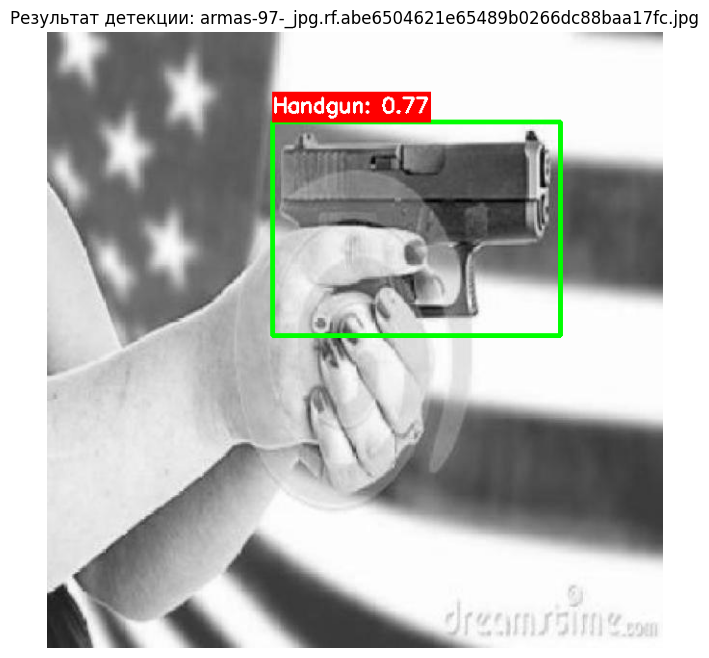
















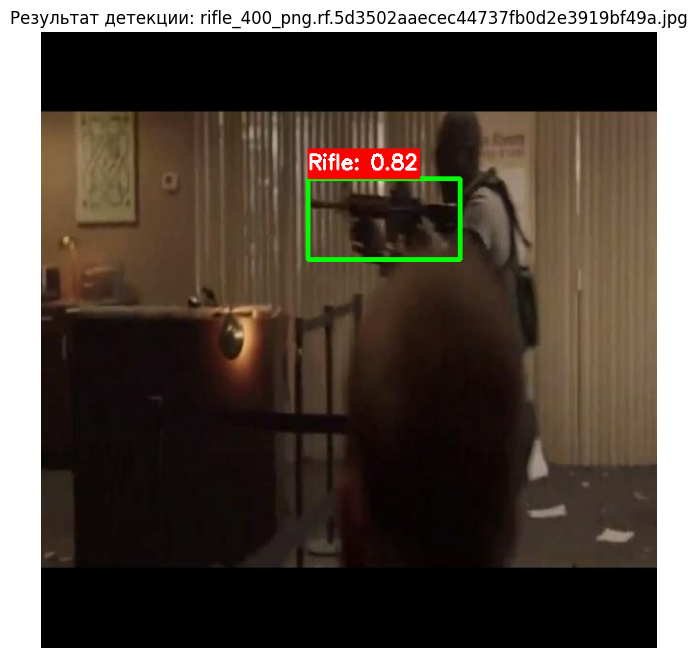

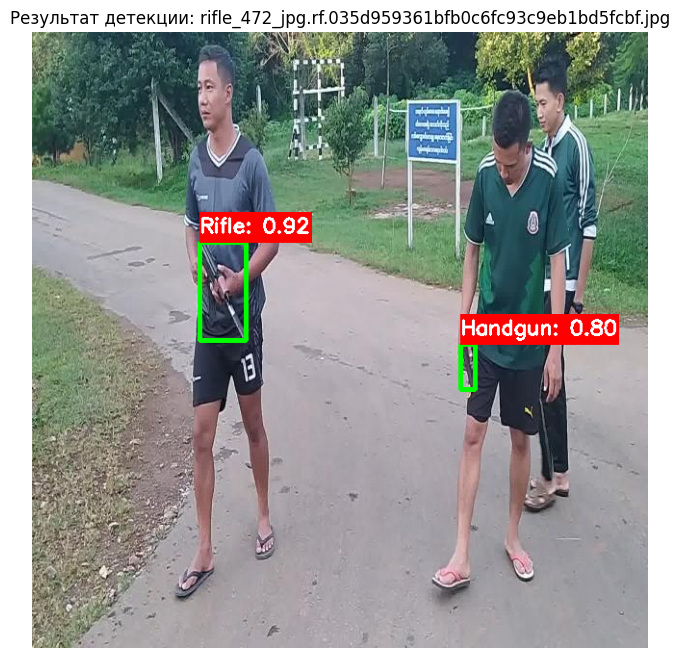

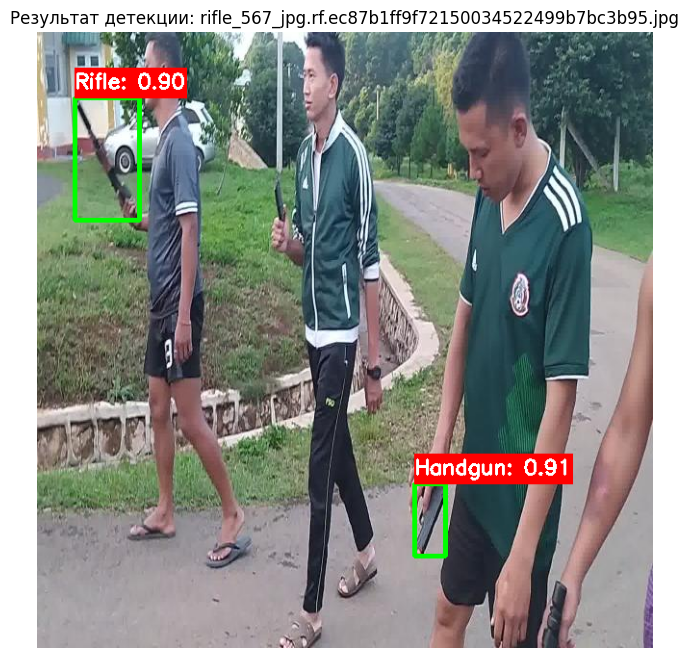

In [ ]:
# установка библиотеки Ультралитикс
!pip install ultralytics

Collecting ultralytics
  Downloading ultralytics-8.4.46-py3-none-any.whl.metadata (39 kB)
Requirement already satisfied: numpy>=1.23.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (2.0.2)
Requirement already satisfied: matplotlib>=3.3.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (3.10.0)
Requirement already satisfied: opencv-python>=4.6.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (4.13.0.92)
Requirement already satisfied: pillow>=7.1.2 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (11.3.0)
Requirement already satisfied: pyyaml>=5.3.1 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (6.0.3)
Requirement already satisfied: requests>=2.23.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (2.32.4)
Requirement already satisfied: scipy>=1.4.1 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (1.16.3)
Requirement already satisfied: torch>=1.8.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (2.10.0+cu128)
Requirement already satisfied: torchvision>=0.9.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (0.25.0+cu128)
Requirement already satisfied: psutil>=5.8.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (5.9.5)
Requirement already satisfied: polars>=0.20.0 in /usr/local/lib/python3.12/dist-packages (from ultralytics) (1.35.2)
Collecting ultralytics-thop>=2.0.18 (from ultralytics)
  Downloading ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
Requirement already satisfied: contourpy>=1.0.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (1.3.3)
Requirement already satisfied: cycler>=0.10 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (0.12.1)
Requirement already satisfied: fonttools>=4.22.0 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (4.61.1)
Requirement already satisfied: kiwisolver>=1.3.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (1.4.9)
Requirement already satisfied: packaging>=20.0 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (26.0)
Requirement already satisfied: pyparsing>=2.3.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (3.3.2)
Requirement already satisfied: python-dateutil>=2.7 in /usr/local/lib/python3.12/dist-packages (from matplotlib>=3.3.0->ultralytics) (2.9.0.post0)
Requirement already satisfied: polars-runtime-32==1.35.2 in /usr/local/lib/python3.12/dist-packages (from polars>=0.20.0->ultralytics) (1.35.2)
Requirement already satisfied: charset_normalizer<4,>=2 in /usr/local/lib/python3.12/dist-packages (from requests>=2.23.0->ultralytics) (3.4.4)
Requirement already satisfied: idna<4,>=2.5 in /usr/local/lib/python3.12/dist-packages (from requests>=2.23.0->ultralytics) (3.11)
Requirement already satisfied: urllib3<3,>=1.21.1 in /usr/local/lib/python3.12/dist-packages (from requests>=2.23.0->ultralytics) (2.5.0)
Requirement already satisfied: certifi>=2017.4.17 in /usr/local/lib/python3.12/dist-packages (from requests>=2.23.0->ultralytics) (2026.1.4)
Requirement already satisfied: filelock in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (3.24.3)
Requirement already satisfied: typing-extensions>=4.10.0 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (4.15.0)
Requirement already satisfied: setuptools in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (75.2.0)
Requirement already satisfied: sympy>=1.13.3 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (1.14.0)
Requirement already satisfied: networkx>=2.5.1 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (3.6.1)
Requirement already satisfied: jinja2 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (3.1.6)
Requirement already satisfied: fsspec>=0.8.5 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (2026.2.0)
Requirement already satisfied: cuda-bindings==12.9.4 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.9.4)
Requirement already satisfied: nvidia-cuda-nvrtc-cu12==12.8.93 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.93)
Requirement already satisfied: nvidia-cuda-runtime-cu12==12.8.90 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.90)
Requirement already satisfied: nvidia-cuda-cupti-cu12==12.8.90 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.90)
Requirement already satisfied: nvidia-cudnn-cu12==9.10.2.21 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (9.10.2.21)
Requirement already satisfied: nvidia-cublas-cu12==12.8.4.1 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.4.1)
Requirement already satisfied: nvidia-cufft-cu12==11.3.3.83 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (11.3.3.83)
Requirement already satisfied: nvidia-curand-cu12==10.3.9.90 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (10.3.9.90)
Requirement already satisfied: nvidia-cusolver-cu12==11.7.3.90 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (11.7.3.90)
Requirement already satisfied: nvidia-cusparse-cu12==12.5.8.93 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.5.8.93)
Requirement already satisfied: nvidia-cusparselt-cu12==0.7.1 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (0.7.1)
Requirement already satisfied: nvidia-nccl-cu12==2.27.5 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (2.27.5)
Requirement already satisfied: nvidia-nvshmem-cu12==3.4.5 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (3.4.5)
Requirement already satisfied: nvidia-nvtx-cu12==12.8.90 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.90)
Requirement already satisfied: nvidia-nvjitlink-cu12==12.8.93 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (12.8.93)
Requirement already satisfied: nvidia-cufile-cu12==1.13.1.3 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (1.13.1.3)
Requirement already satisfied: triton==3.6.0 in /usr/local/lib/python3.12/dist-packages (from torch>=1.8.0->ultralytics) (3.6.0)
Requirement already satisfied: cuda-pathfinder~=1.1 in /usr/local/lib/python3.12/dist-packages (from cuda-bindings==12.9.4->torch>=1.8.0->ultralytics) (1.3.5)
Requirement already satisfied: six>=1.5 in /usr/local/lib/python3.12/dist-packages (from python-dateutil>=2.7->matplotlib>=3.3.0->ultralytics) (1.17.0)
Requirement already satisfied: mpmath<1.4,>=1.1.0 in /usr/local/lib/python3.12/dist-packages (from sympy>=1.13.3->torch>=1.8.0->ultralytics) (1.3.0)
Requirement already satisfied: MarkupSafe>=2.0 in /usr/local/lib/python3.12/dist-packages (from jinja2->torch>=1.8.0->ultralytics) (3.0.3)
Downloading ultralytics-8.4.46-py3-none-any.whl (1.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
Downloading ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)
Installing collected packages: ultralytics-thop, ultralytics
Successfully installed ultralytics-8.4.46 ultralytics-thop-2.0.19

In [ ]:
import torch
from ultralytics import YOLO
from pathlib import Path
from tqdm import tqdm

# 1. Пути (укажите свои)
YOLO_MODEL_PATH = "/kaggle/input/models/ekaterinamorozova29/gun-yolo11s/pytorch/default/1/standard_hyper.pt"
TEST_DATASET_PATH = "/kaggle/input/datasets/ekaterinamorozova29/coco-gun-dataset2/coco_gundataset/test"

# 2. Инициализация и загрузка весов
# Для YOLO веса загружаются сразу при создании объекта
yolo_model = YOLO(YOLO_MODEL_PATH)
yolo_model.to("cuda")

# 3. Формируем список путей (тот же самый, что и для RF-DETR)
test_images = [str(p) for p in Path(TEST_DATASET_PATH).glob("**/*.jpg")]
print(f"✅ Список готов: {len(test_images)} изображений для YOLO")

# 4. Цикл инференса
yolo_results_data = []

for img_path in tqdm(test_images, desc="Расчет метрик YOLO"):
    try:
        # Пытаемся получить предсказание
        # conf=0.25 — такой же порог, как и в RF-DETR для честности
        results = yolo_model.predict(img_path, conf=0.25, verbose=False)

        # У YOLO results — это список, берем первый элемент (т.к. обрабатываем по 1 фото)
        # results[0].boxes содержит все найденные рамки
        num_objects = len(results[0].boxes)
        yolo_results_data.append(num_objects)

    except Exception as e:
        print(f"❌ Ошибка на файле {img_path}: {e}")
        break

# 5. Вывод сводки
if yolo_results_data:
    print(f"\n--- Сравнение результатов ---")
    print(f"YOLO: Среднее кол-во объектов на фото: {sum(yolo_results_data)/len(yolo_results_data):.2f}")
    # Сюда можно подставить данные из первого скрипта
    # print(f"RF-DETR: Среднее кол-во объектов на фото: {sum(results_data)/len(results_data):.2f}")

Creating new Ultralytics Settings v0.0.6 file ✅
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Список готов: 135 изображений для YOLO
Расчет метрик YOLO: 100%|██████████| 135/135 [00:02<00:00, 63.01it/s]
--- Сравнение результатов ---
- **YOLOv11s со стандартными гиперпараметрами: Среднее кол-во объектов на фото: 1.19**

**Вывод по проделанной работе:** трансформер определяет оружие чуть хуже чем модель YOLO со стандартными гиперпараметрами. Скорее всего потому что 5 эпох это мало для трансформера, так как  максимальная длина сессии на Кэгле 12 часов, в дальнейшем буду работать над этой проблемой.